In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
from collections import defaultdict, Counter
from underthesea import word_tokenize
import urllib.request
import regex
import os

In [2]:
metadata_path = Path("full_content_metadata")

files = []

for file_path in metadata_path.rglob("*.json"):
    files.append(file_path)
print(f'[LOG] Tổng số files: {len(files)}')

[LOG] Tổng số files: 4042


In [4]:
with open(files[90], 'r') as f:
    test_sample = json.load(f)
pprint(test_sample)

{'author_metadata': {'comment_setting': 0,
                     'create_time': 1561791627,
                     'download_setting': 0,
                     'duet_setting': 0,
                     'ftc': False,
                     'id': 6695589739796808705,
                     'is_ad_virtual': False,
                     'name': 'Hà Thu',
                     'open_favorite': False,
                     'private_account': False,
                     'recommend_reason': '',
                     'relation': 0,
                     'secret': False,
                     'signature': 'Contact work : kol@adbiz.vn',
                     'stitch_setting': 0,
                     'suggest_account_bind': False,
                     'username': 'hathuchaybo01',
                     'verified': False},
 'comment_metadata': {'comments': [{'avatar': 'https://p16-sign-sg.tiktokcdn.com/tos-alisg-avt-0068/9473b5b3081b7484e0b61bfac3052c61~tplv-tiktokx-cropcenter:100:100.jpg?dr=14579&refresh_token=e8935

In [5]:
print(test_sample['hashtags_metadata'][0]['name'])

hathuchaybo


In [27]:
for file in files[220:225]:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    hashtags =  data['video_metadata']['hashtags']
    caption = data['video_metadata']['description']
    diversification_labels = data['video_metadata']['diversification_labels']
    if not hashtags_metadata:
        continue

    print(f"\nFile: {file}")
    print(f"Full caption: {caption}")
    print(f"hashtags: {hashtags}")
    print(f'Labels: {diversification_labels}')


File: content_metadata/Adult Content/milanaz.vn_7462351185861725458.json
Full caption: con cac 
hashtags: []
Labels: ['Random Shoot', 'Others']

File: content_metadata/Adult Content/kienthuckhoahoc64_7589239042718453023.json
Full caption: Lông Cứng Ở Nam Giới Chức Năng Bảo Vệ Ít Ai Biết #learnontiktok #kienthuc #khoahoc #suckhoe #xh 
hashtags: ['learnontiktok', 'kienthuc', 'khoahoc', 'suckhoe', 'xh']
Labels: ['Humanities', 'Education', 'Culture & Education & Technology']

File: content_metadata/Adult Content/liilykhanh_7547877975312583952.json
Full caption: cảnh đẹp nên quay chơi 
hashtags: []
Labels: ['Finger Dance & Basic Dance', 'Singing & Dancing', 'Talents']

File: content_metadata/Adult Content/duythang404_7598165303465463061.json
Full caption: Tự nhiên mê siêu nhân ngang vậy á #xuhuong #tiktok #sieunhan #baby 
hashtags: ['xuhuong', 'tiktok', 'sieunhan', 'baby']
Labels: None

File: content_metadata/Adult Content/emsuaday2_7524145343026580754.json
Full caption: Động lực của ba #t


🔍 Top 3 hashtag bị loại bỏ (xuất hiện nhiều nhất toàn cục):
  #fyp: 1120 lần
  #xuhuong: 513 lần
  #viral: 418 lần
['Adult Content', 'Harmful Content', 'Safe', 'Suicide']


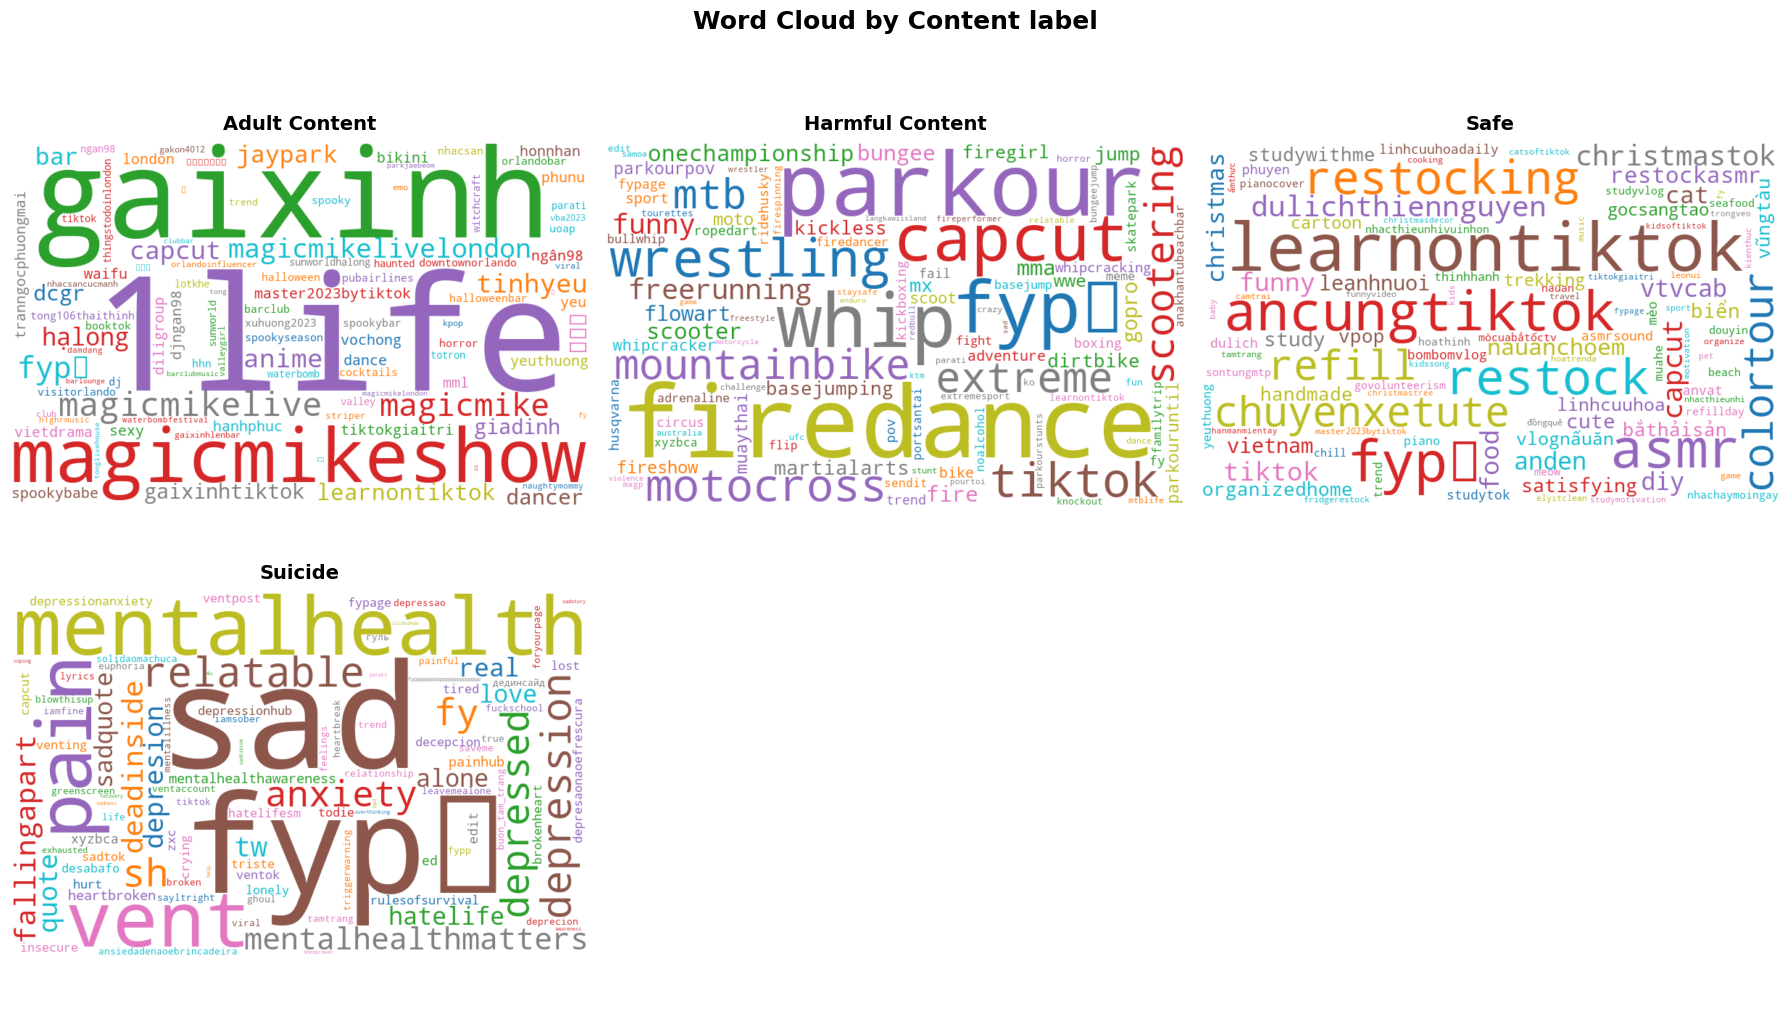

In [3]:
from wordcloud import WordCloud

def get_all_text_by_label(files):
    """Gom toàn bộ text hashstag theo từng label"""
    text_by_label = defaultdict(list)

    for file in files:
        label = os.path.basename(os.path.dirname(file))
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        hashtags_metadata = data['hashtags_metadata']
        if not hashtags_metadata:
            continue
        for h in hashtags_metadata:
            name = h.get("name", "").strip()
            if name:
                text_by_label[label].append(name)

    return text_by_label

def get_global_stopwords(text_by_label, top_n=20):
    """
    Tìm top_n hashtag xuất hiện nhiều nhất trên tất cả nhãn
    → dùng làm stopwords tự động
    """
    global_counter = Counter()
    for hashtags in text_by_label.values():
        global_counter.update(hashtags)

    common = global_counter.most_common(top_n)
    print(f"\n🔍 Top {top_n} hashtag bị loại bỏ (xuất hiện nhiều nhất toàn cục):")
    for tag, count in common:
        print(f"  #{tag}: {count} lần")

    return set(tag for tag, _ in common)

def draw_wordclouds(text_by_labelg, lobal_stopwords=None, extra_stopwords=None):
    # Kết hợp stopwords
    stopwords = set()
    if global_stopwords:
        stopwords.update(global_stopwords)
    if extra_stopwords:
        stopwords.update(extra_stopwords)
    
    labels = sorted(text_by_label.keys())
    print(labels)
    n = len(labels)
    
    # Tính số hàng/cột cho subplot
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
    axes = axes.flatten()

    for i, label in enumerate(labels):
        filtered = [tag for tag in text_by_label[label] if tag not in stopwords]
        all_text = " ".join(filtered)

        wc = WordCloud(
            width=800,
            height=500,
            background_color="white",
            max_words=100,
            colormap="tab10",
            collocations=False,  # Tránh lặp cụm từ
            regexp=r"\w+",       # Tách từ, bỏ emoji nếu muốn giữ text thuần
        ).generate(all_text)

        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(label, fontsize=14, fontweight="bold", pad=10)

    # Ẩn các subplot thừa
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Word Cloud by Content label", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# ── Chạy ──────────────────────────────────────────────
EXTRA_STOPWORDS = {
    "fyp", "foryou", "foryoupage", "viral", "trending","xh", "xuhuongtiktok", "viralvideo",'fyp'
}

text_by_label = get_all_text_by_label(files)

global_stopwords = get_global_stopwords(text_by_label, top_n=3)  # ← chỉnh top_n tuỳ ý

draw_wordclouds(text_by_label, global_stopwords, EXTRA_STOPWORDS)

## Hashtag segmentation

In [4]:
import py_vncorenlp
py_vncorenlp.download_model(save_dir='/Users/nnam/Documents/Workspace/university/mguard/sentiment_analysist/vncorenlp')

VnCoreNLP model folder /Users/nnam/Documents/Workspace/university/mguard/sentiment_analysist/vncorenlp already exists! Please load VnCoreNLP from this folder!


In [5]:
rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/Users/nnam/Documents/Workspace/university/mguard/sentiment_analysist/vncorenlp')


2026-03-04 23:47:09 INFO  WordSegmenter:24 - Loading Word Segmentation model


In [8]:
text = "#chuyenxetute"
output = rdrsegmenter.word_segment(text)
print(output)

['# chuyenxetute']
